# Configuración previa

## Importación de librerías

In [ ]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

import random

import tensorflow as tf

from collections import Counter

from tensorflow.keras.preprocessing.image import ImageDataGenerator

2025-03-20 12:47:30.955115: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 12:47:30.959505: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-03-20 12:47:30.971521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742474850.991508   41486 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742474850.997758   41486 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1742474851.012787   41486 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

## Replicabilidad

In [25]:
seed = 0
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)

## GPU

In [26]:
if tf.config.list_physical_devices('GPU'):
    print("GPU is available")
else:
    print("GPU is not available")

physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        tf.config.experimental.set_virtual_device_configuration(
            physical_devices[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=4096)]
        )
        print("GPU configured")
    except RuntimeError as e:
        print(e)

GPU is not available


E0000 00:00:1742474853.444933   41486 cuda_executor.cc:1228] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1742474853.445756   41486 gpu_device.cc:2341] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Comprobación de estructura de las imágenes

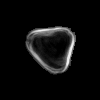

In [2]:
sample = Image.open("data/Tipo_A_Kunzea/Kunzea_12.png")
sample

In [3]:
np.max(np.array(sample)), np.array(sample).shape, np.array(sample)

(np.uint8(241),
 (100, 100),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

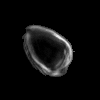

In [4]:
sample = Image.open("data/Tipo_B_Lepto/Lepto_50.png")
sample

In [5]:
np.max(np.array(sample)), np.array(sample).shape, np.array(sample)

(np.uint8(242),
 (100, 100),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], dtype=uint8))

# Carga y preprocesamiento

## Carga

### Datos

In [6]:
directory_A = './data/Tipo_A_Kunzea'
directory_B = './data/Tipo_B_Lepto'


files_A = os.listdir(directory_A)
files_B = os.listdir(directory_B)


if not (len(files_A) == len(files_B) == 1200):
    raise Exception("Error in files. Check the filespath.")


lists_A = []
lists_B = []

for index in range(1200):
    temp_A = Image.open(os.path.join(directory_A, files_A[index]))
    lists_A.append(np.array(temp_A) / 255)
    
    temp_B = Image.open(os.path.join(directory_B, files_B[index]))
    lists_B.append(np.array(temp_B) / 255)



images_A = np.array(lists_A).reshape(-1, 100, 100, 1)
images_B = np.array(lists_B).reshape(-1, 100, 100, 1)

images_A.shape, images_B.shape

((1200, 100, 100, 1), (1200, 100, 100, 1))

In [10]:
data = np.concatenate((images_A, images_B))
labels = np.concatenate((np.full(1200, 'Tipo A - Kunzea'), np.full(1200, 'Tipo B - Lepto')))

data.shape

(2400, 100, 100, 1)

### Etiquetas

In [ ]:
# le = LabelEncoder()



# labels_encoded = le.fit_transform(labels_name)

## Preprocesamiento

### División de conjuntos

In [14]:
X_train, X_temp, y_train, y_temp = train_test_split(data, labels, test_size=0.30, stratify=labels, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)


X_train.shape, X_val.shape, X_test.shape

((1680, 100, 100, 1), (360, 100, 100, 1), (360, 100, 100, 1))

In [ ]:
print(Counter(y_train).most_common())
print(Counter(y_val).most_common())
print(Counter(y_test).most_common())

[(np.str_('Tipo A - Kunzea'), 840), (np.str_('Tipo B - Lepto'), 840)]
[(np.str_('Tipo B - Lepto'), 180), (np.str_('Tipo A - Kunzea'), 180)]
[(np.str_('Tipo B - Lepto'), 180), (np.str_('Tipo A - Kunzea'), 180)]


### Data Augmentation

In [108]:
datagen = ImageDataGenerator(
    rotation_range=10,         # Rotación máxima de 10 grados
    width_shift_range=0.05,     # Desplazamiento horizontal del 10%
    height_shift_range=0.05,    # Desplazamiento vertical del 10%
    zoom_range=0.1,            # Zoom entre 0.9x y 1.1x
    # brightness_range=[0.8, 1.2],  # Cambio de brillo entre 0.8 y 1.2
    # horizontal_flip=True,
    fill_mode='reflect'        # Rellena áreas vacías con el píxel más cercano # nearest, reflect
)

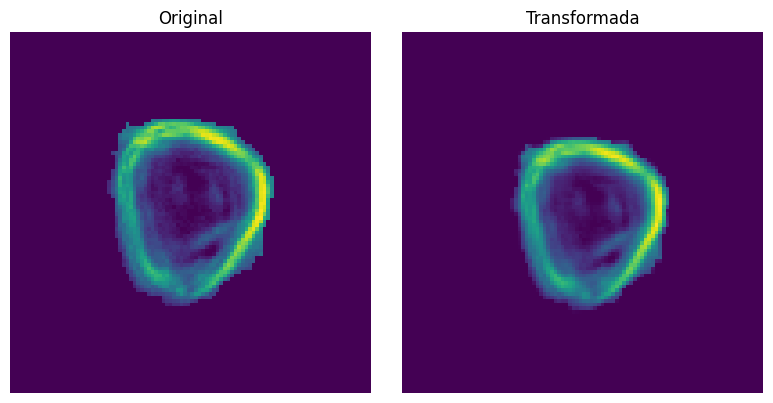

In [ ]:
original_image = X_train[0]

transformed_image = datagen.random_transform(original_image)

# Visualizar
plt.figure(figsize=(8, 4))

# Imagen original
plt.subplot(1, 2, 1)
plt.imshow(original_image.squeeze())#, cmap='gray') 
plt.title("Original")
plt.axis("off")

# Imagen transformada
plt.subplot(1, 2, 2)
plt.imshow(transformed_image.squeeze())#, cmap='gray')
plt.title("Transformada")
plt.axis("off")

plt.tight_layout()
plt.show()

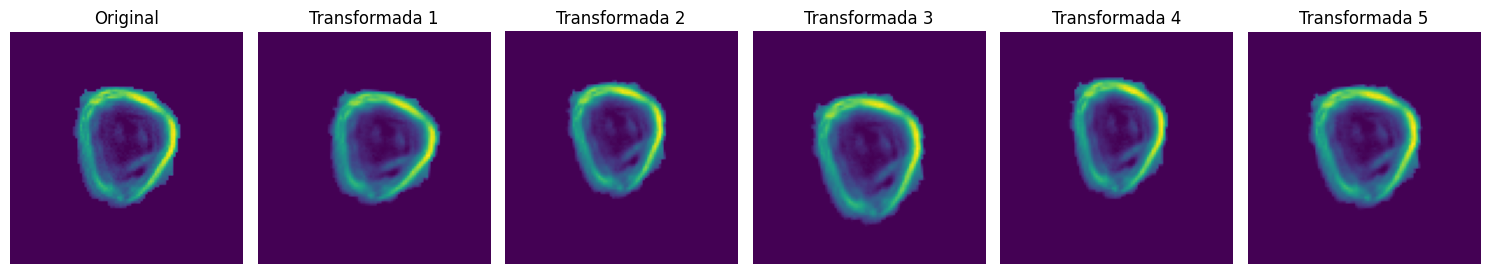

In [109]:
original_image = X_train[0]

augmented_images = [datagen.random_transform(original_image) for _ in range(5)]

# Crear figura con 6 columnas (original + 5 transformaciones)
plt.figure(figsize=(15, 3))

# Mostrar original
plt.subplot(1, 6, 1)
plt.imshow(original_image.squeeze())
plt.title("Original")
plt.axis("off")

# Mostrar transformaciones
for i in range(5):
    plt.subplot(1, 6, i + 2)
    plt.imshow(augmented_images[i].squeeze())
    plt.title(f"Transformada {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [135]:
import numpy as np

def generate_samples(X_train, y_train, datagen=datagen, n_samples=10):

    syntetic_samples = []
    
    for image in X_train:  
        images_list = [datagen.random_transform(image) for _ in range(n_samples)]
        syntetic_samples.extend(images_list)
    
    data = np.concatenate((X_train, syntetic_samples))
    labels = np.concatenate((y_train, np.repeat(y_train, n_samples)))

    return data, labels

In [137]:
X_train_augmented, y_train_augmented = generate_samples(X_train, y_train)

X_train_augmented.shape, y_train_augmented.shape

((18480, 100, 100, 1), (18480,))